# WTI COT Release — Impact on Forward Price Returns

When the CFTC releases the COT report on Friday, does the revealed
positioning predict where WTI price goes next?

- **Event**: Friday COT release
- **Signal**: MM net change, MM net level, MM net/OI
- **Forward returns**: from Friday close to +1d, +1w, +2w, +4w

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load COT + daily prices

In [2]:
COT_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'

raw = pd.read_csv(COT_PATH, low_memory=False)
wti = raw[raw['contract_market_name'] == 'WTI-PHYSICAL'].copy()

wti['as_of_date'] = pd.to_datetime(wti['report_date_as_yyyy_mm_dd'])
days_ahead = (4 - wti['as_of_date'].dt.dayofweek) % 7
wti['release_date'] = wti['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
wti['open_interest'] = pd.to_numeric(wti['open_interest_all'], errors='coerce')
wti['mm_long']  = pd.to_numeric(wti['m_money_positions_long_all'], errors='coerce')
wti['mm_short'] = pd.to_numeric(wti['m_money_positions_short_all'], errors='coerce')
wti['mm_net']   = wti['mm_long'] - wti['mm_short']

wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

cot = wti[['as_of_date', 'release_date', 'mm_net', 'mm_long', 'mm_short',
           'open_interest']].copy()
cot['mm_net_oi'] = cot['mm_net'] / cot['open_interest'] * 100
cot['mm_net_chg'] = cot['mm_net'].diff()
cot['mm_net_oi_chg'] = cot['mm_net_oi'].diff()

print(f'COT rows: {len(cot)}')
print(f'Range: {cot["as_of_date"].min().date()} -> {cot["as_of_date"].max().date()}')

COT rows: 1032
Range: 2006-06-13 -> 2026-03-17


In [3]:
prices = pd.read_csv('../../cache/preprocessed_data/wti_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)
prices.reset_index(drop=True, inplace=True)

print(f'Daily prices: {len(prices)} rows')
print(f'Range: {prices["tradeDate"].min().date()} -> {prices["tradeDate"].max().date()}')

Daily prices: 3921 rows
Range: 2010-01-04 -> 2025-08-05


## 2. Compute forward returns from Friday close

In [4]:
# For each release Friday, find the Friday close price and
# forward prices at +1d, +5d, +10d, +20d
FORWARD_DAYS = [1, 5, 10, 20]
FORWARD_LABELS = {1: '+1d (Mon)', 5: '+1w', 10: '+2w', 20: '+4w'}

# Build a price lookup by date
price_series = prices.set_index('tradeDate')['F1_RolledPrice']

# For each release Friday, find the closest price
cot_sorted = cot.dropna(subset=['mm_net_chg']).sort_values('release_date').copy()

# Merge Friday close price
df = pd.merge_asof(
    cot_sorted,
    prices.rename(columns={'tradeDate': 'release_date', 'F1_RolledPrice': 'price_fri'}),
    on='release_date', direction='backward', tolerance=pd.Timedelta(days=3),
)

# Compute forward returns: find price N business days after release
for n_days in FORWARD_DAYS:
    fwd_prices = []
    for _, row in df.iterrows():
        # Find the N-th business day after release_date
        future = prices[prices['tradeDate'] > row['release_date']]
        if len(future) >= n_days:
            fwd_prices.append(future.iloc[n_days - 1]['F1_RolledPrice'])
        else:
            fwd_prices.append(np.nan)
    df[f'price_fwd_{n_days}d'] = fwd_prices
    df[f'fwd_ret_{n_days}d'] = (df[f'price_fwd_{n_days}d'] / df['price_fri'] - 1) * 100

df.dropna(subset=['price_fri', 'mm_net_chg'] + [f'fwd_ret_{d}d' for d in FORWARD_DAYS],
          inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Clean rows: {len(df)}')
print(f'Range: {df["release_date"].min().date()} -> {df["release_date"].max().date()}')
print(f'Missing fwd returns: {df[[f"fwd_ret_{d}d" for d in FORWARD_DAYS]].isna().sum().to_dict()}')

Clean rows: 809
Range: 2010-01-08 -> 2025-07-04
Missing fwd returns: {'fwd_ret_1d': 0, 'fwd_ret_5d': 0, 'fwd_ret_10d': 0, 'fwd_ret_20d': 0}


## 3. Correlation: COT signals vs forward returns

In [5]:
SIGNALS = {
    'MM net change':    'mm_net_chg',
    'MM net/OI change': 'mm_net_oi_chg',
    'MM net level':     'mm_net',
    'MM net/OI level':  'mm_net_oi',
}

# Full-sample Spearman
results = []
for sig_label, sig_col in SIGNALS.items():
    for n_days in FORWARD_DAYS:
        ret_col = f'fwd_ret_{n_days}d'
        rho, p = sp_stats.spearmanr(df[sig_col], df[ret_col])
        results.append({
            'Signal': sig_label,
            'Forward': FORWARD_LABELS[n_days],
            'rho': rho,
            'p-value': p,
            'significant': p < 0.05,
        })

res_df = pd.DataFrame(results)

# Pivot for display
rho_pivot = res_df.pivot(index='Signal', columns='Forward', values='rho')[[
    FORWARD_LABELS[d] for d in FORWARD_DAYS
]]
p_pivot = res_df.pivot(index='Signal', columns='Forward', values='p-value')[[
    FORWARD_LABELS[d] for d in FORWARD_DAYS
]]

print('Spearman rho: COT signal vs forward return from Friday close')
print(rho_pivot.round(3).to_string())
print()
print('p-values:')
print(p_pivot.applymap(lambda x: f'{x:.1e}').to_string())

Spearman rho: COT signal vs forward return from Friday close
Forward           +1d (Mon)    +1w    +2w    +4w
Signal                                          
MM net change        -0.002 -0.022  0.002 -0.005
MM net level          0.027  0.010  0.018  0.021
MM net/OI change      0.002 -0.021 -0.009  0.000
MM net/OI level       0.015  0.011  0.009  0.013

p-values:
Forward          +1d (Mon)      +1w      +2w      +4w
Signal                                               
MM net change      9.6e-01  5.2e-01  9.6e-01  8.9e-01
MM net level       4.4e-01  7.8e-01  6.2e-01  5.4e-01
MM net/OI change   9.6e-01  5.5e-01  8.0e-01  1.0e+00
MM net/OI level    6.7e-01  7.6e-01  7.9e-01  7.1e-01


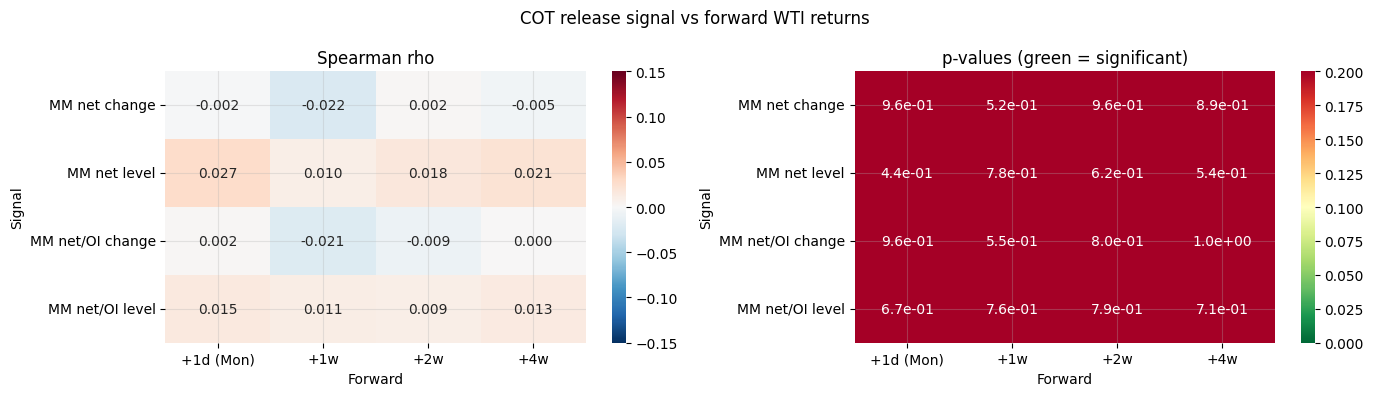

In [6]:
# Heatmap: rho
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
sns.heatmap(rho_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-0.15, vmax=0.15, ax=ax)
ax.set_title('Spearman rho')

ax = axes[1]
sns.heatmap(p_pivot, annot=True, fmt='.1e', cmap='RdYlGn_r', ax=ax,
            vmin=0, vmax=0.2)
ax.set_title('p-values (green = significant)')

plt.suptitle('COT release signal vs forward WTI returns', fontsize=12)
plt.tight_layout()
plt.show()

## 4. By quintile: average forward return by COT signal bucket

Sort weeks by the COT signal into 5 buckets. Does the average
forward return increase monotonically across buckets?

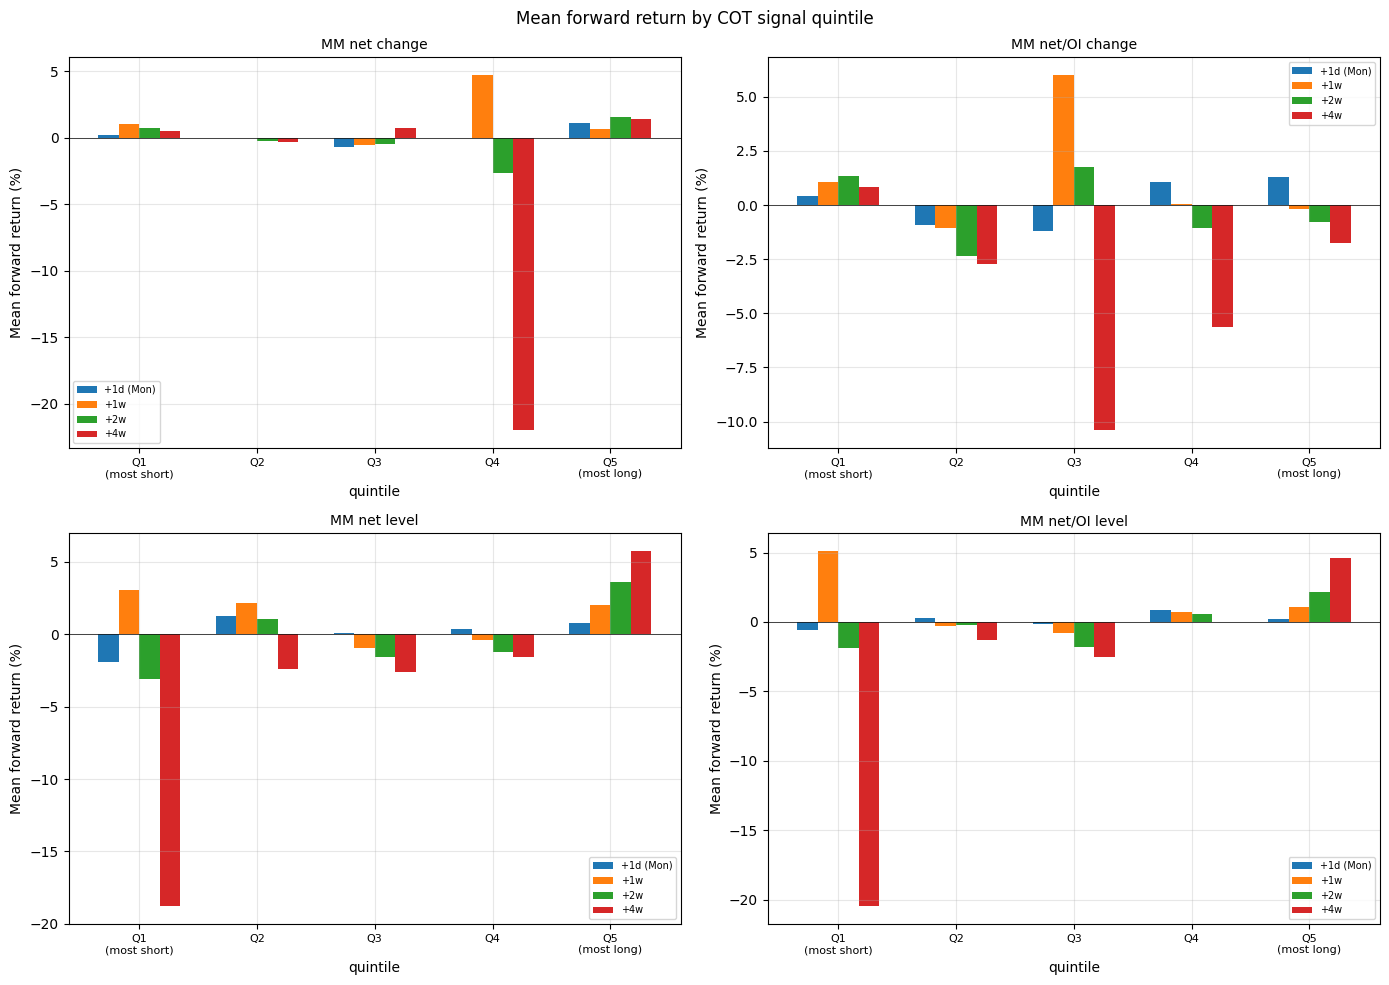

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (sig_label, sig_col) in zip(axes.flat, SIGNALS.items()):
    df['quintile'] = pd.qcut(df[sig_col], 5, labels=['Q1\n(most short)', 'Q2', 'Q3', 'Q4', 'Q5\n(most long)'])

    means = df.groupby('quintile')[[f'fwd_ret_{d}d' for d in FORWARD_DAYS]].mean()
    means.columns = [FORWARD_LABELS[d] for d in FORWARD_DAYS]

    means.plot.bar(ax=ax, width=0.7)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(sig_label, fontsize=10)
    ax.set_ylabel('Mean forward return (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Mean forward return by COT signal quintile', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Stability over time: 3-year blocks

MM net change vs forward returns — by 3-year block
             n  +1d (Mon)    +1w    +2w    +4w
Block                                         
2010-2012  156     -0.049 -0.155 -0.137 -0.080
2013-2015  156      0.068  0.060  0.130  0.120
2016-2018  157     -0.010 -0.013 -0.113 -0.139
2019-2021  157      0.124  0.010  0.013  0.031
2022-2025  183     -0.122 -0.069  0.062  0.012



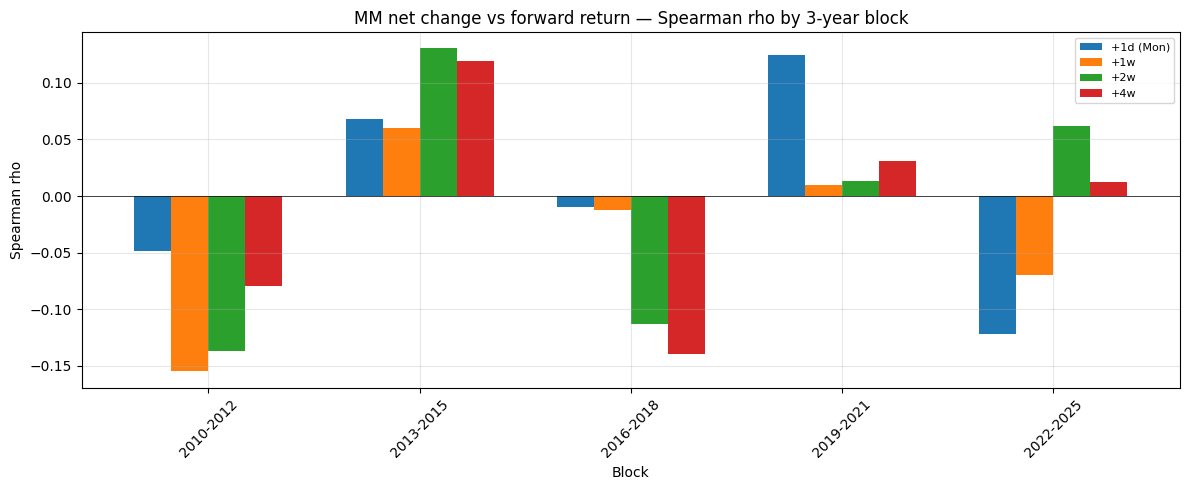

In [8]:
df['year'] = df['release_date'].dt.year

blocks = [
    ('2010-2012', (2010, 2012)),
    ('2013-2015', (2013, 2015)),
    ('2016-2018', (2016, 2018)),
    ('2019-2021', (2019, 2021)),
    ('2022-2025', (2022, 2025)),
]

# Focus on mm_net_chg vs each forward horizon
sig_col = 'mm_net_chg'

block_results = []
for label, (y_start, y_end) in blocks:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    row = {'Block': label, 'n': len(sub)}
    for n_days in FORWARD_DAYS:
        rho, p = sp_stats.spearmanr(sub[sig_col], sub[f'fwd_ret_{n_days}d'])
        row[FORWARD_LABELS[n_days]] = rho
        row[f'p_{n_days}d'] = p
    block_results.append(row)

block_df = pd.DataFrame(block_results).set_index('Block')

print('MM net change vs forward returns — by 3-year block')
print(block_df[[c for c in block_df.columns if not c.startswith('p_')]].round(3).to_string())
print()

# Bar chart
plot_cols = [FORWARD_LABELS[d] for d in FORWARD_DAYS]
fig, ax = plt.subplots(figsize=(12, 5))
block_df[plot_cols].plot.bar(ax=ax, width=0.7)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('MM net change vs forward return — Spearman rho by 3-year block')
ax.set_ylabel('Spearman rho')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Extreme positioning: do extremes predict reversals?

When MM is at extreme net long or net short (top/bottom decile of net/OI),
does price tend to reverse?

In [9]:
q10 = df['mm_net_oi'].quantile(0.10)
q90 = df['mm_net_oi'].quantile(0.90)

extreme_short = df[df['mm_net_oi'] <= q10]
extreme_long  = df[df['mm_net_oi'] >= q90]
middle        = df[(df['mm_net_oi'] > q10) & (df['mm_net_oi'] < q90)]

print(f'Extreme short (bottom 10%): {len(extreme_short)} weeks, net/OI <= {q10:.1f}%')
print(f'Extreme long  (top 10%):    {len(extreme_long)} weeks, net/OI >= {q90:.1f}%')
print(f'Middle:                     {len(middle)} weeks')
print()

print(f'{"Regime":>20s}', end='')
for d in FORWARD_DAYS:
    print(f'  {FORWARD_LABELS[d]:>8s}', end='')
print()
print('-' * (22 + 10 * len(FORWARD_DAYS)))

for label, sub in [('Extreme short', extreme_short),
                    ('Middle', middle),
                    ('Extreme long', extreme_long)]:
    print(f'{label:>20s}', end='')
    for d in FORWARD_DAYS:
        mean_ret = sub[f'fwd_ret_{d}d'].mean()
        print(f'  {mean_ret:>+8.2f}', end='')
    print()

print()
print('If extremes predict reversals: extreme long → negative forward returns,')
print('extreme short → positive forward returns.')

Extreme short (bottom 10%): 81 weeks, net/OI <= 4.5%
Extreme long  (top 10%):    81 weeks, net/OI >= 12.6%
Middle:                     647 weeks

              Regime  +1d (Mon)       +1w       +2w       +4w
--------------------------------------------------------------
       Extreme short     -4.17     +5.29     -7.72    -39.76
              Middle     +0.72     +0.80     +0.53     -0.33
        Extreme long     -0.26     +0.09     +1.18     +3.16

If extremes predict reversals: extreme long → negative forward returns,
extreme short → positive forward returns.


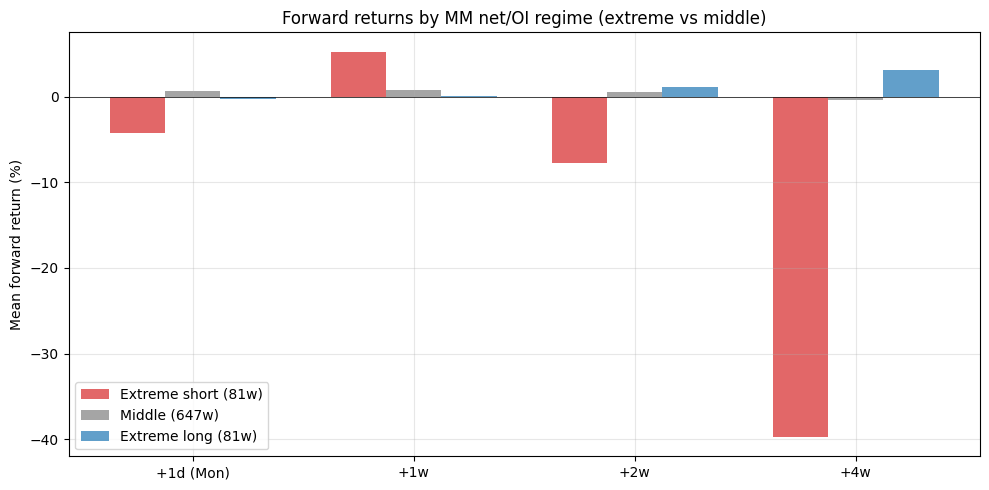

In [10]:
# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(FORWARD_DAYS))
w = 0.25

for i, (label, sub, color) in enumerate([
    ('Extreme short', extreme_short, 'tab:red'),
    ('Middle', middle, 'tab:grey'),
    ('Extreme long', extreme_long, 'tab:blue'),
]):
    means = [sub[f'fwd_ret_{d}d'].mean() for d in FORWARD_DAYS]
    ax.bar(x + (i - 1) * w, means, w, label=f'{label} ({len(sub)}w)',
           color=color, alpha=0.7)

ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels([FORWARD_LABELS[d] for d in FORWARD_DAYS])
ax.set_ylabel('Mean forward return (%)')
ax.set_title('Forward returns by MM net/OI regime (extreme vs middle)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Extreme positioning by 3-year block

Is the extreme signal stable, or driven by a particular period (e.g. COVID)?

In [11]:
for label_block, (y_start, y_end) in blocks:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    if len(sub) < 30:
        continue

    # Compute deciles within each block (not global)
    q10_b = sub['mm_net_oi'].quantile(0.10)
    q90_b = sub['mm_net_oi'].quantile(0.90)

    ext_short = sub[sub['mm_net_oi'] <= q10_b]
    ext_long  = sub[sub['mm_net_oi'] >= q90_b]
    mid       = sub[(sub['mm_net_oi'] > q10_b) & (sub['mm_net_oi'] < q90_b)]

    print(f'\n=== {label_block} ({len(sub)} weeks) ===')
    print(f'  Extreme short: net/OI <= {q10_b:.1f}% ({len(ext_short)}w)')
    print(f'  Extreme long:  net/OI >= {q90_b:.1f}% ({len(ext_long)}w)')
    print()
    print(f'{"Regime":>20s}', end='')
    for d in FORWARD_DAYS:
        print(f'  {FORWARD_LABELS[d]:>8s}', end='')
    print()
    print('-' * (22 + 10 * len(FORWARD_DAYS)))
    for rlabel, rsub in [('Extreme short', ext_short),
                          ('Middle', mid),
                          ('Extreme long', ext_long)]:
        print(f'{rlabel:>20s}', end='')
        for d in FORWARD_DAYS:
            mean_ret = rsub[f'fwd_ret_{d}d'].mean()
            print(f'  {mean_ret:>+8.2f}', end='')
        print()



=== 2010-2012 (156 weeks) ===
  Extreme short: net/OI <= 4.4% (16w)
  Extreme long:  net/OI >= 9.4% (16w)

              Regime  +1d (Mon)       +1w       +2w       +4w
--------------------------------------------------------------
       Extreme short     +0.26     +1.27     +1.51     +2.21
              Middle     +0.10     +0.01     +0.07     +0.10
        Extreme long     +0.34     -0.70     -1.23     -1.59

=== 2013-2015 (156 weeks) ===
  Extreme short: net/OI <= 5.5% (16w)
  Extreme long:  net/OI >= 14.1% (16w)

              Regime  +1d (Mon)       +1w       +2w       +4w
--------------------------------------------------------------
       Extreme short     -0.69     -1.20     -3.32     -5.05
              Middle     -0.35     -0.73     -1.43     -3.23
        Extreme long     +0.13     +0.01     -0.18     +0.85

=== 2016-2018 (157 weeks) ===
  Extreme short: net/OI <= 4.8% (16w)
  Extreme long:  net/OI >= 13.1% (16w)

              Regime  +1d (Mon)       +1w       +2w       

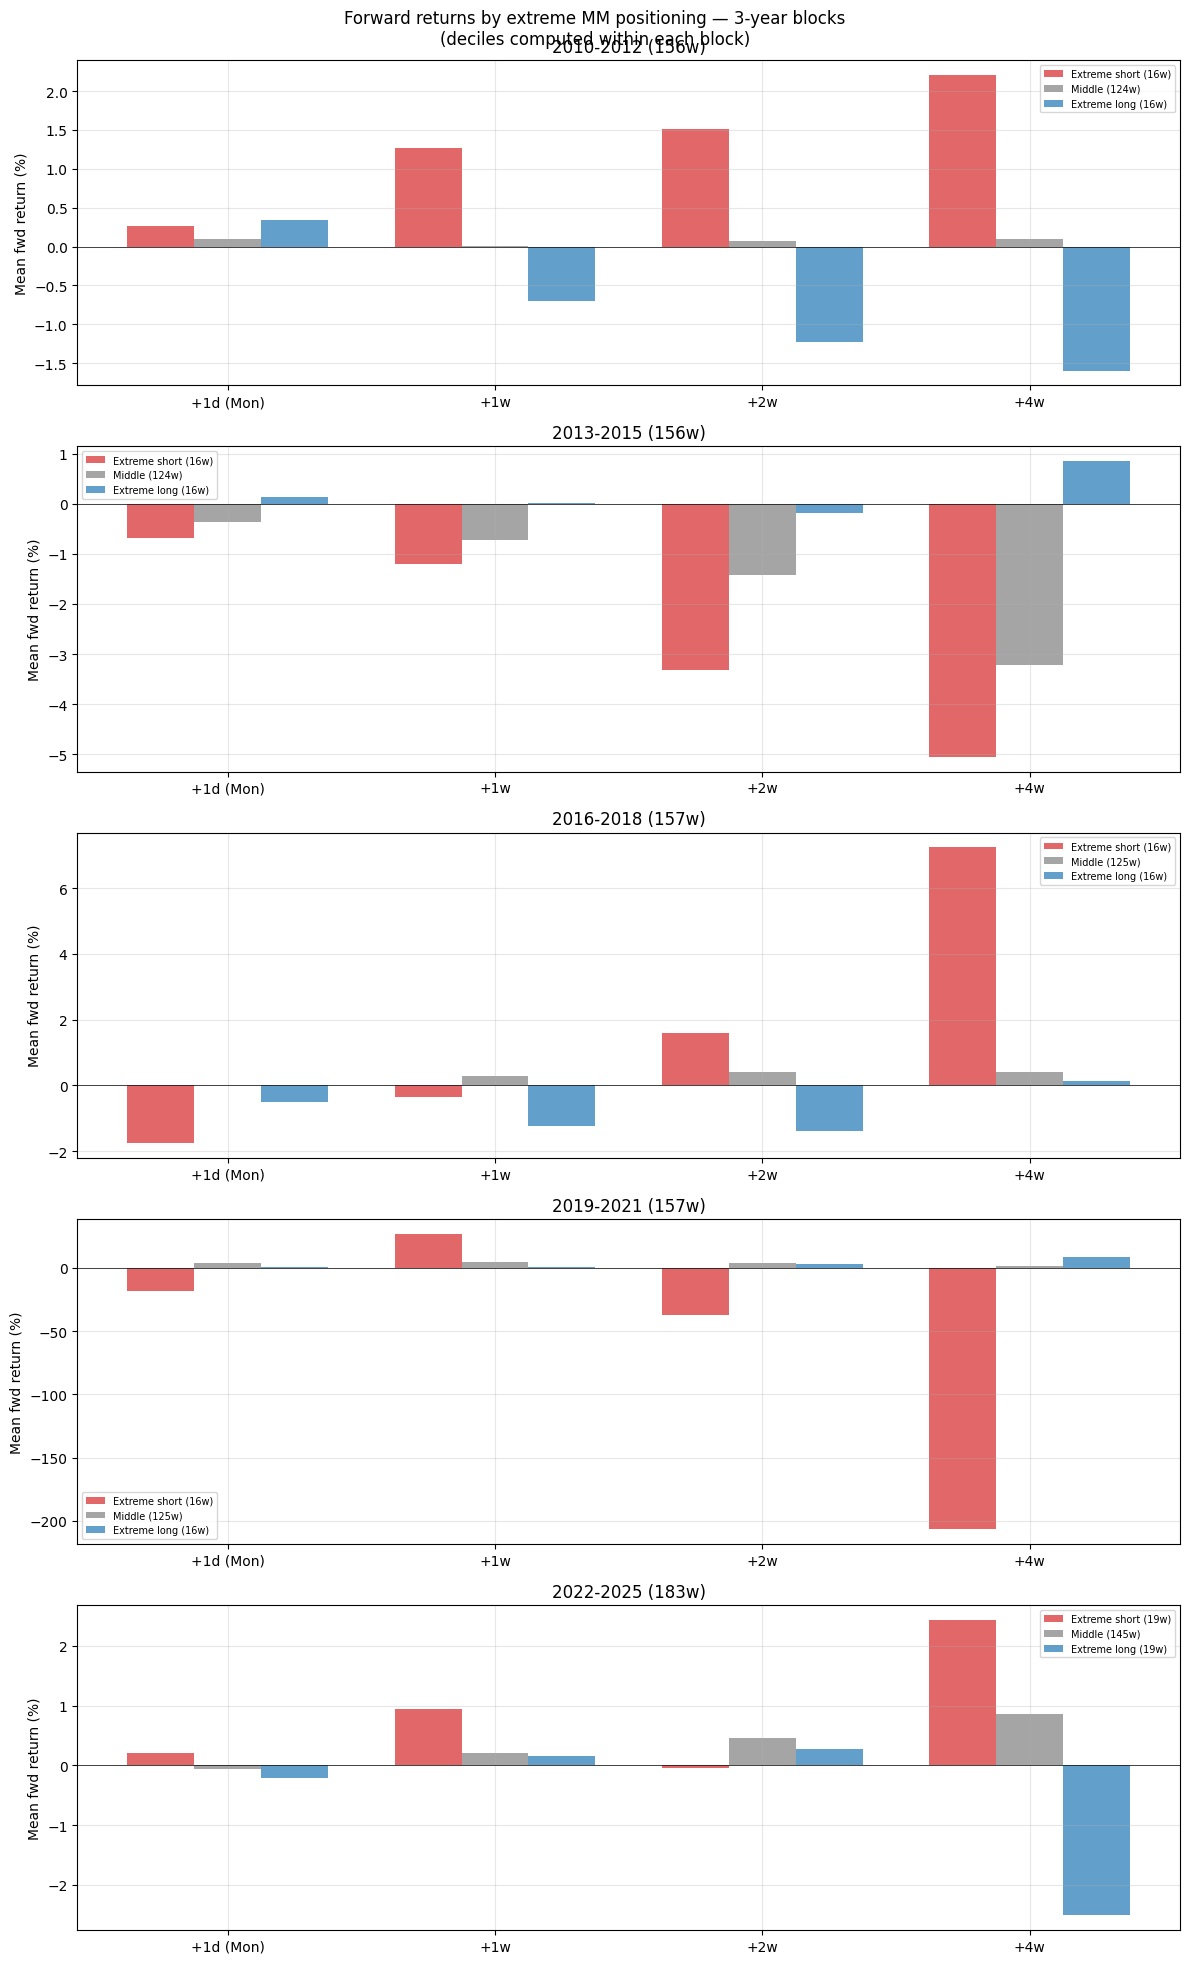

In [12]:
# Visualise: one panel per block
fig, axes = plt.subplots(len(blocks), 1, figsize=(12, 4 * len(blocks)))

for ax, (label_block, (y_start, y_end)) in zip(axes, blocks):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    q10_b = sub['mm_net_oi'].quantile(0.10)
    q90_b = sub['mm_net_oi'].quantile(0.90)

    regimes = [
        ('Extreme short', sub[sub['mm_net_oi'] <= q10_b], 'tab:red'),
        ('Middle', sub[(sub['mm_net_oi'] > q10_b) & (sub['mm_net_oi'] < q90_b)], 'tab:grey'),
        ('Extreme long', sub[sub['mm_net_oi'] >= q90_b], 'tab:blue'),
    ]

    x = np.arange(len(FORWARD_DAYS))
    w = 0.25
    for i, (rlabel, rsub, color) in enumerate(regimes):
        means = [rsub[f'fwd_ret_{d}d'].mean() for d in FORWARD_DAYS]
        ax.bar(x + (i - 1) * w, means, w, label=f'{rlabel} ({len(rsub)}w)',
               color=color, alpha=0.7)

    ax.axhline(0, color='black', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([FORWARD_LABELS[d] for d in FORWARD_DAYS])
    ax.set_ylabel('Mean fwd return (%)')
    ax.set_title(f'{label_block} ({len(sub)}w)')
    ax.legend(fontsize=7, loc='best')

plt.suptitle('Forward returns by extreme MM positioning — 3-year blocks\n'
             '(deciles computed within each block)', fontsize=12)
plt.tight_layout()
plt.show()
